In [25]:
device = "cuda"

# Sample Weight Test

This notebook validates the `sample_weight` feature in PackBoost.

**Setup:** The training set has two regimes:
- **Early samples** (first ~70%): the true signal is buried in heavy noise — a weak version of the real relationship
- **Late samples** (last ~30%): clean signal identical to the val/test distribution

**Hypothesis:** a model trained with weights that upweight the late (clean) samples should learn the true relationship better than a model with uniform weights.

## 1. Setup — Imports

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from packboost.core import PackBoost
from packboost.callback import EarlyStoppingCallback

## 2. Generate Training Data with Distribution Shift

The training set is split into two regimes:
- **Early 70k samples**: signal is dominated by "wrong" features (X[:,3], X[:,4]) + heavy noise
- **Late 30k samples**: signal matches val/test exactly (X[:,0], X[:,1], X[:,2] + light noise)

Val and test use only the true relationship.

In [27]:
np.random.seed(42)

N_early = 70_000   # noisy/wrong-feature samples
N_late  = 30_000   # clean samples matching val/test
N_train = N_early + N_late
N_val   = 2_000
N_test  = 500
N_feat  = 20

X_train = np.random.randint(0, 4, (N_train, N_feat), dtype='i1')
X_val   = np.random.randint(0, 4, (N_val,   N_feat), dtype='i1')
X_test  = np.random.randint(0, 4, (N_test,  N_feat), dtype='i1')

def make_y_true(X_):
    """True relationship (used by val, test, and late train samples)."""
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        + 0.22 * X_[:, 2].astype('f4')
        + 0.01 * np.random.randn(len(X_)).astype('f4')
    )

def make_y_noisy(X_):
    """Misleading relationship (early train): wrong features + high noise."""
    return (
        0.05 * X_[:, 0].astype('f4')          # true signal, but very weak
        + 0.40 * X_[:, 3].astype('f4')        # irrelevant feature, strong
        + 0.35 * X_[:, 4].astype('f4')        # irrelevant feature, strong
        + 0.25 * np.random.randn(len(X_)).astype('f4')  # heavy noise
    )

y_early = make_y_noisy(X_train[:N_early])
y_late  = make_y_true(X_train[N_early:])
y_train_raw = np.concatenate([y_early, y_late])

y_val_raw  = make_y_true(X_val)
y_test_raw = make_y_true(X_test)

print(f"Train shape : {X_train.shape}  (early={N_early}, late={N_late})")
print(f"Val shape   : {X_val.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"y_train range: [{y_train_raw.min():.3f}, {y_train_raw.max():.3f}]")

Train shape : (100000, 20)  (early=70000, late=30000)
Val shape   : (2000, 20)
Test shape  : (500, 20)
y_train range: [-0.906, 3.253]


## 3. Preprocess & Bucketize Targets

Scale all targets to [0, 1] using the train scaler, then bucketize into 4 bins.

In [28]:
scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_scaled   = scaler.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_scaled  = scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

bins   = [0, 0.25, 0.5, 0.75, 1.0]
labels = [0.125, 0.375, 0.625, 0.875]

def bucketize(y_scaled):
    return np.array(
        pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True),
        dtype=float
    ).astype(np.float32)

y_train = bucketize(y_train_scaled)
y_val   = bucketize(y_val_scaled)
y_test  = bucketize(y_test_scaled)

print(f"y_train unique: {np.unique(y_train)}")
print(f"y_val   unique: {np.unique(y_val)}")
print(f"y_test  unique: {np.unique(y_test)}")

y_train unique: [0.125 0.375 0.625 0.875]
y_val   unique: [0.125 0.375 0.625 0.875]
y_test  unique: [0.125 0.375 0.625 0.875]


## 4. Train — No Sample Weights (baseline)

In [ ]:
# Base hyperparams shared by both runs.
# L2 and min_child_weight are calibrated for mean(w) = 1.
# The weighted run scales them by mean(w) to keep regularisation equivalent.
BASE_KWARGS = dict(
    rounds=1000,
    max_depth=8,
    nfolds=4,
    lr=0.1,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device,
    min_split_gain=0.0,
    max_delta_step=3.0
)
L2_BASE         = 1_000.0   # regularisation at mean(w) = 1
MIN_CHILD_BASE  =   100.0   # min leaf hessian-mass at mean(w) = 1

FIT_KWARGS = dict(**BASE_KWARGS, L2=L2_BASE, min_child_weight=MIN_CHILD_BASE)

es_no_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_no_w = PackBoost(device=device)
t0 = time.time()
model_no_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
               callbacks=[es_no_w], **FIT_KWARGS)
print(f"No-weights training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_no_w.best_tree_set}, best val r={es_no_w.best_score:.4f})")

[Round 10] improved -> score=2.272057e-01
[Round 20] improved -> score=2.981952e-01
[Round 30] improved -> score=2.995217e-01
[Round 40] improved -> score=3.003751e-01
[Round 50] no improve 1/50 | 0.3003750954470591
[Round 60] improved -> score=3.081458e-01
[Round 70] improved -> score=3.096121e-01
[Round 80] improved -> score=3.096572e-01
[Round 90] improved -> score=3.124715e-01
[Round 100] improved -> score=3.128654e-01
[Round 110] no improve 1/50 | 0.3128653626185808
[Round 120] no improve 2/50 | 0.3128653626185808
[Round 130] no improve 3/50 | 0.3128653626185808
[Round 140] no improve 4/50 | 0.3128653626185808
[Round 150] no improve 5/50 | 0.3128653626185808
[Round 160] no improve 6/50 | 0.3128653626185808
[Round 170] no improve 7/50 | 0.3128653626185808
[Round 180] no improve 8/50 | 0.3128653626185808
[Round 190] no improve 9/50 | 0.3128653626185808
[Round 200] no improve 10/50 | 0.3128653626185808
[Round 210] no improve 11/50 | 0.3128653626185808
[Round 220] no improve 12/50 | 0

## 5. Train — With Sample Weights

Early samples receive weight **1**, late samples receive weight **10**.
This tells the model "the last 30k samples are 10x more representative of the true distribution."

In [30]:
# Early samples: w=1 (low trust)
# Late  samples: w=10 (high trust — match val/test distribution)
sample_weight = np.ones(N_train, dtype=np.float32)
sample_weight[N_early:] = 10.0

w_mean = float(sample_weight.mean())   # 3.7  — used to scale min_child_weight
w_max  = float(sample_weight.max())    # 10.0 — used to scale L2

# L2 must be scaled by w_max (not w_mean) to prevent overshooting.
# Leaf value for a w=10-dominated node:
#   leaf ≈ lr * w_max * ΣG / (w_max * L2_base) = lr * ΣG / L2_base  ✓
# If L2 were only scaled by w_mean (3.7), that same leaf would step (w_max/w_mean)=2.7x
# too aggressively — producing better correlation but worse R² (overshooting).
# min_child_weight tracks the minimum hessian mass (Σw) needed in a child, so
# it scales with w_mean (average weight mass per sample).

print(f"Weight distribution: early={np.unique(sample_weight[:N_early])}, "
      f"late={np.unique(sample_weight[N_early:])}")
print(f"Effective sample count: early={sample_weight[:N_early].sum():.0f}, "
      f"late={sample_weight[N_early:].sum():.0f}")
print(f"w_mean={w_mean:.3f}, w_max={w_max:.0f}")
print(f"  → L2={L2_BASE * w_max:.0f}  (×w_max, caps step size for heavy-weight leaves)")
print(f"  → min_child_weight={MIN_CHILD_BASE * w_mean:.0f}  (×w_mean, preserves data-mass threshold)")

FIT_KWARGS_W = dict(**BASE_KWARGS,
                    L2=L2_BASE * w_max,
                    min_child_weight=MIN_CHILD_BASE * w_mean)

es_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_w = PackBoost(device=device)
t0 = time.time()
model_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
            sample_weight=sample_weight, callbacks=[es_w], **FIT_KWARGS_W)
print(f"Weighted training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_w.best_tree_set}, best val r={es_w.best_score:.4f})")

Weight distribution: early=[1.], late=[10.]
Effective sample count: early=70000, late=300000
w_mean=3.700, w_max=10
  → L2=10000  (×w_max, caps step size for heavy-weight leaves)
  → min_child_weight=370  (×w_mean, preserves data-mass threshold)
[Round 10] improved -> score=3.102407e-01
[Round 20] no improve 1/50 | 0.31024066434267894
[Round 30] no improve 2/50 | 0.31024066434267894
[Round 40] no improve 3/50 | 0.31024066434267894
[Round 50] no improve 4/50 | 0.31024066434267894
[Round 60] no improve 5/50 | 0.31024066434267894
[Round 70] no improve 6/50 | 0.31024066434267894
[Round 80] no improve 7/50 | 0.31024066434267894
[Round 90] no improve 8/50 | 0.31024066434267894
[Round 100] no improve 9/50 | 0.31024066434267894
[Round 110] no improve 10/50 | 0.31024066434267894
[Round 120] no improve 11/50 | 0.31024066434267894
[Round 130] no improve 12/50 | 0.31024066434267894
[Round 140] no improve 13/50 | 0.31024066434267894
[Round 150] no improve 14/50 | 0.31024066434267894
[Round 160] no 

## 6. Compare Metrics

In [31]:
def evaluate(model, X, y_true, label):
    preds = model.predict(X) / (1 << 30)
    r = np.corrcoef(preds, y_true)[0, 1]
    ss_res = np.sum((y_true - preds) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return {"model": label, "Pearson r": round(float(r), 4), "R²": round(float(r2), 4)}, preds

metrics_no_w, preds_no_w = evaluate(model_no_w, X_test, y_test, "No weights")
metrics_w,    preds_w    = evaluate(model_w,    X_test, y_test, "With weights (late=10x)")

results = pd.DataFrame([metrics_no_w, metrics_w]).set_index("model")
print(results.to_string())
print()
print(f"Delta Pearson r : {metrics_w['Pearson r'] - metrics_no_w['Pearson r']:+.4f}")
print(f"Delta R²        : {metrics_w['R²'] - metrics_no_w['R²']:+.4f}")

                         Pearson r       R²
model                                      
No weights                  0.4542   0.1120
With weights (late=10x)     0.3551 -11.9553

Delta Pearson r : -0.0991
Delta R²        : -12.0673


## 7. Visualize — True vs Predicted & Residuals

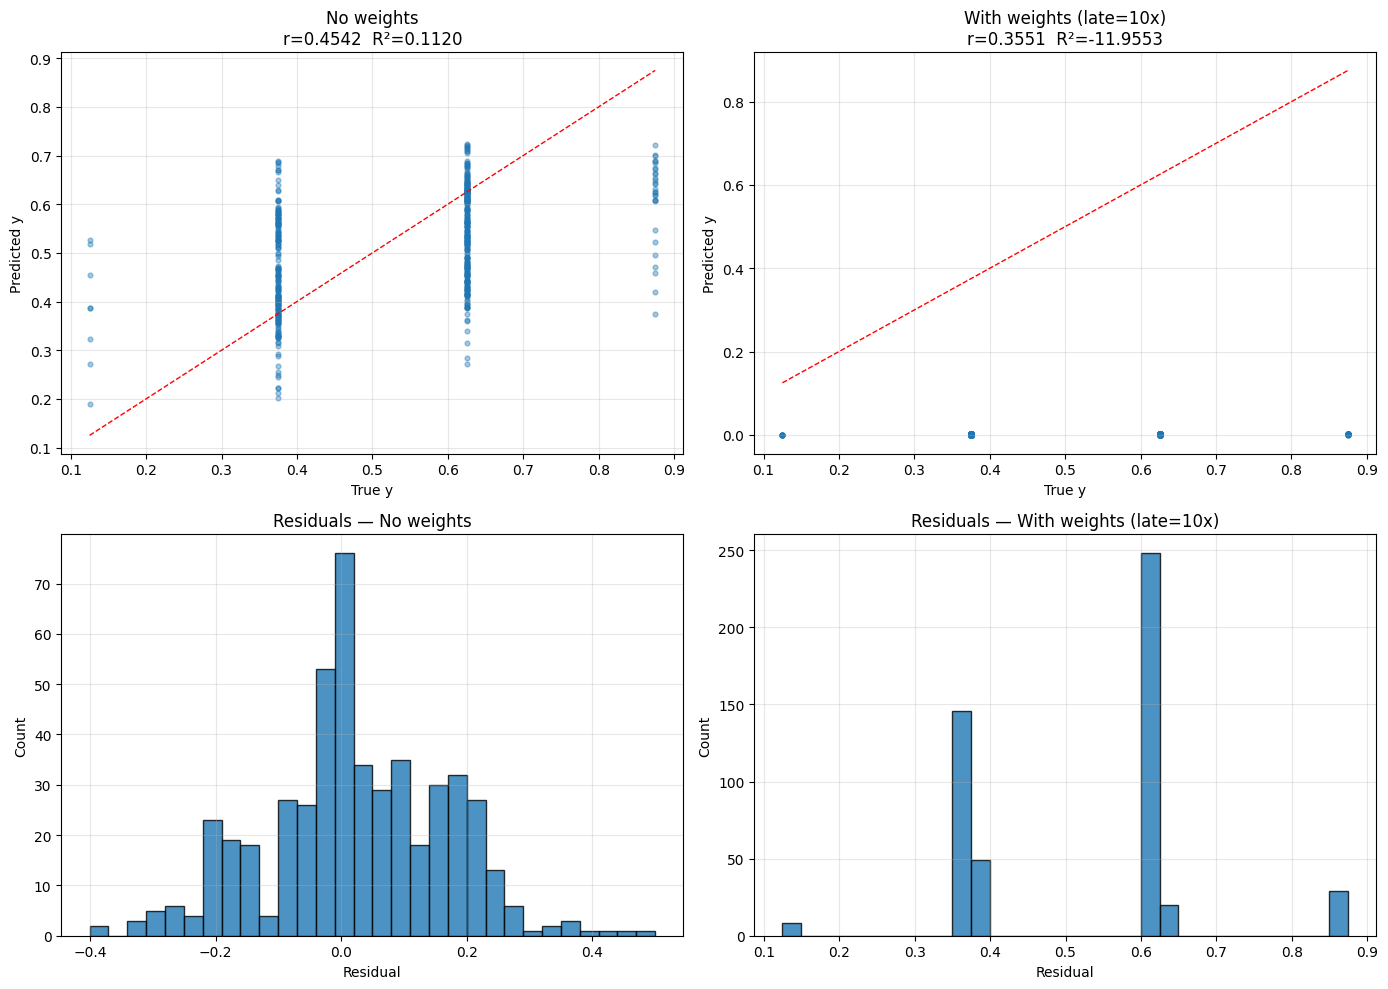

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (preds, m) in enumerate([(preds_no_w, metrics_no_w), (preds_w, metrics_w)]):
    r, r2 = m["Pearson r"], m["R²"]
    label = m["model"]

    # scatter
    ax = axes[0, col]
    ax.scatter(y_test, preds, alpha=0.4, s=12)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")
    ax.set_title(f"{label}\nr={r:.4f}  R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

    # residuals
    ax = axes[1, col]
    ax.hist(y_test - preds, bins=30, edgecolor='black', alpha=0.8)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(f"Residuals — {label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()